# Univariate Distances — Visualisation & Analysis (Chap)

Loads pre-computed distances from `distances_all_datasets_chap.csv` and runs:
- Per-dataset mean ± std intervals (Section 4)
- Overall summary statistics (Section 5)
- Variance decomposition — nested ANOVA (Section 6)

In [16]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

OUT_DIR = os.path.join(os.getcwd(), 'UNIVARIATE RESEMBLANCE RESULTS')
os.makedirs(OUT_DIR, exist_ok=True)

# ── The cells below are kept for reference but are NOT needed when loading
#    from the pre-computed CSV (use the Shortcut cell instead) ───────────────
# FUNCTIONS_HOME = '../../../functions/evaluation_functions/'
REAL_DATA_HOME = '../../../data/raw/chap/'
SYN_DATA_HOME  = '../../../data/processed/chap/'
# FUNCTIONS_DIR  = 'EVALUATION FUNCTIONS/RESEMBLANCE'
# META_ECDF      = '.../run_log_ecdf.csv'
# META_CTGAN     = '.../run_log_ctgan.csv'
# ACTUAL_DIR = os.getcwd()
# os.chdir(FUNCTIONS_HOME + FUNCTIONS_DIR)
# from univariate_resemblance import scale_data, cosine_distances, js_distances, wass_distances
# os.chdir(ACTUAL_DIR)

---
**Shortcut** — if `distances_all_datasets_chap.csv` already exists, run the cell below and skip sections 1–3.

In [17]:
# ── Load pre-computed results (skip sections 1–3 if CSV already exists) ─────
OUT_DIR = os.path.join(os.getcwd(), 'UNIVARIATE RESEMBLANCE RESULTS')
out_raw = os.path.join(OUT_DIR, 'distances_all_datasets_chap.csv')

df_results = pd.read_csv(out_raw)
print(f"Loaded: {out_raw}")
print(f"Shape: {df_results.shape}")
df_results.head()

Loaded: /Users/hazel/Dropbox/jinyuan/synthetic_data/review_paper/STDG-evaluation-metrics/notebooks/Dataset 1 - Chap/Synthetic data evaluation/Resemblance/UNIVARIATE RESEMBLANCE RESULTS/distances_all_datasets_chap.csv
Shape: (2000, 7)


,method,imp_id,syn_id,variable,cosine,js,wasserstein
0,ecdf,1.0,1.0,sbp_bin1,0.260550,0.039274,0.005987
1,ecdf,1.0,1.0,sbp_bin2,0.160776,0.035440,0.004358
2,ecdf,1.0,1.0,sbp_bin3,0.117736,0.033674,0.049116
3,ecdf,1.0,1.0,sbp_bin4,0.151418,0.037514,0.008612
4,ecdf,1.0,1.0,sbp_bin5,0.099262,0.030050,0.004020


In [18]:
n_vars = df_results['variable'].nunique()

# For each (method, imp_id, syn_id): mean of each distance across n_vars variables
df_ds = (
    df_results
    .groupby(['method', 'imp_id', 'syn_id'])[['cosine', 'js', 'wasserstein']]
    .mean()
    .reset_index()
)
df_ds.columns = ['method', 'imp_id', 'syn_id', 'cosine_mean', 'js_mean', 'wasserstein_mean']

# Sort by imp_id then syn_id; assign sequential index 1–50 per method
df_ds = df_ds.sort_values(['method', 'imp_id', 'syn_id']).reset_index(drop=True)
df_ds['ds_idx'] = df_ds.groupby('method').cumcount() + 1

out_ds = os.path.join(OUT_DIR, 'distances_per_dataset_means_chap.csv')
df_ds.to_csv(out_ds, index=False)
print(f"Saved: {out_ds}  (shape: {df_ds.shape})")
df_ds.head(10)

Saved: /Users/hazel/Dropbox/jinyuan/synthetic_data/review_paper/STDG-evaluation-metrics/notebooks/Dataset 1 - Chap/Synthetic data evaluation/Resemblance/UNIVARIATE RESEMBLANCE RESULTS/distances_per_dataset_means_chap.csv  (shape: (100, 7))


,method,imp_id,syn_id,cosine_mean,js_mean,wasserstein_mean,ds_idx
0,ctgan,1.0,1.0,0.123969,0.036901,0.076478,1
1,ctgan,1.0,2.0,0.123038,0.036885,0.077510,2
2,ctgan,1.0,3.0,0.123345,0.036912,0.079891,3
3,ctgan,1.0,4.0,0.127076,0.037298,0.080907,4
4,ctgan,1.0,5.0,0.122092,0.036729,0.078131,5
5,ctgan,1.0,6.0,0.124758,0.037042,0.081258,6
6,ctgan,1.0,7.0,0.121818,0.036669,0.080737,7
7,ctgan,1.0,8.0,0.124158,0.036940,0.072274,8
8,ctgan,1.0,9.0,0.122350,0.036722,0.079954,9
9,ctgan,1.0,10.0,0.123811,0.036547,0.078937,10


## 4b. Per-imputation boxplots (IQR across 10 syntheses)

For each metric: horizontal boxplots with **y = imputation 1–5**, **x = distance value**.  
Each box summarises the 10 synthesis runs for that imputation (IQR + whiskers).  
Left panel = ECDF, right panel = CTGAN. Shared x-axis per metric.

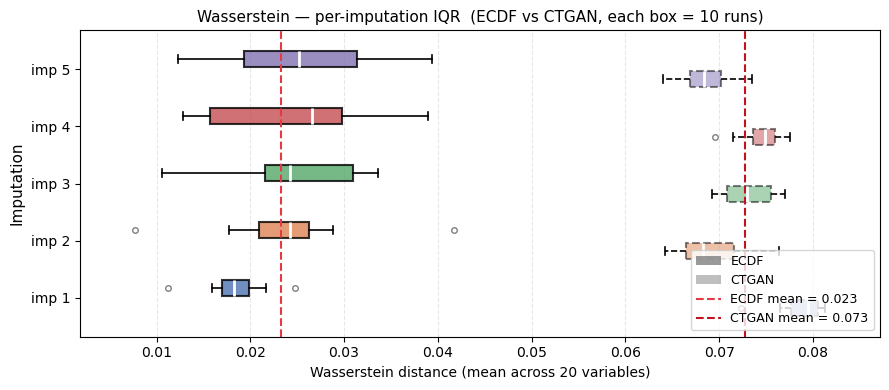

Saved: /Users/hazel/Dropbox/jinyuan/synthetic_data/review_paper/STDG-evaluation-metrics/notebooks/Dataset 1 - Chap/Synthetic data evaluation/Resemblance/UNIVARIATE RESEMBLANCE RESULTS/boxplot_byimp_wasserstein_combined_chap.svg


In [19]:
METRIC       = 'wasserstein'
METRIC_LABEL = 'Wasserstein'
IMP_IDS      = sorted(df_ds['imp_id'].unique())
IMP_PALETTE  = dict(zip(IMP_IDS, ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']))

col    = f'{METRIC}_mean'
vals   = df_ds[col]
margin = (vals.max() - vals.min()) * 0.08
xlim   = (max(0.0, vals.min() - margin), vals.max() + margin)

fig, ax = plt.subplots(figsize=(9, 4))

offsets = {'ecdf': +0.18, 'ctgan': -0.18}
alphas  = {'ecdf': 0.80,  'ctgan': 0.50}
lstyles = {'ecdf': '-',   'ctgan': '--'}
mean_colors = {'ecdf': '#e63946', 'ctgan': '#c1121f'}

for method in ['ecdf', 'ctgan']:
    sub  = df_ds[df_ds['method'] == method]
    data = [sub[sub['imp_id'] == imp][col].values for imp in IMP_IDS]
    pos  = [i + offsets[method] for i in range(1, 6)]

    bp = ax.boxplot(
        data,
        vert         = False,
        patch_artist = True,
        positions    = pos,
        widths       = 0.28,
        medianprops  = dict(color='white', linewidth=2),
        whiskerprops = dict(linewidth=1.2, linestyle=lstyles[method]),
        capprops     = dict(linewidth=1.2),
        flierprops   = dict(marker='o', markersize=4, alpha=0.5),
    )
    for box, imp in zip(bp['boxes'], IMP_IDS):
        box.set_facecolor(IMP_PALETTE[imp])
        box.set_alpha(alphas[method])
        box.set_linestyle(lstyles[method])
        box.set_linewidth(1.5)

    # overall mean vertical line per method
    m = sub[col].mean()
    ax.axvline(m, color=mean_colors[method], lw=1.5, ls='--',
               label=f'{method.upper()} mean = {m:.3f}')

ax.set_xlim(xlim)
ax.set_yticks(range(1, 6))
ax.set_yticklabels([f'imp {int(i)}' for i in IMP_IDS], fontsize=10)
ax.set_xlabel(f'{METRIC_LABEL} distance (mean across {n_vars} variables)', fontsize=10)
ax.set_ylabel('Imputation', fontsize=11)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_title(
    f'{METRIC_LABEL} — per-imputation IQR  (ECDF vs CTGAN, each box = 10 runs)',
    fontsize=11
)

box_handles = [
    Patch(facecolor='grey', alpha=0.80, label='ECDF'),
    Patch(facecolor='grey', alpha=0.50, linestyle='--', label='CTGAN'),
]
mean_handles = ax.get_legend_handles_labels()
ax.legend(handles=box_handles + list(mean_handles[0][-2:]),
          fontsize=9, loc='lower right')

fig.tight_layout()
fname = os.path.join(OUT_DIR, f'boxplot_byimp_{METRIC}_combined_chap.svg')
fig.savefig(fname, bbox_inches='tight')
plt.show()
print(f"Saved: {fname}")

In [20]:
summary = (
    df_results
    .groupby('method')[['cosine', 'js', 'wasserstein']]
    .agg(['mean', 'std', 'median'])
    .round(5)
)
summary.columns = ['_'.join(c) for c in summary.columns]
print("Overall summary (all variables pooled):")
summary

Overall summary (all variables pooled):


,cosine_mean,cosine_std,cosine_median,js_mean,js_std,js_median,wasserstein_mean,wasserstein_std,wasserstein_median
method,,,,,,,,,
ctgan,0.11488,0.03985,0.10870,0.0362,0.00756,0.03627,0.07276,0.05983,0.05292
ecdf,0.10436,0.05066,0.09513,0.0320,0.00836,0.03245,0.02324,0.03592,0.00608


## 5. Variance Decomposition (Nested ANOVA)

**Setup:** $M = 5$ imputations $\times$ $L = 10$ syntheses $= 50$ observations per method.  
Each observation $y_{ij}$ = mean Wasserstein distance across 20 variables for imputation $i$, synthesis $j$.

**Sum-of-squares decomposition (exact identity):**

$$\underbrace{\sum_{i=1}^{M}\sum_{j=1}^{L}(y_{ij}-\bar{y})^2}_{\text{SS}_{\text{total}}}
= \underbrace{\sum_{i=1}^{M}\sum_{j=1}^{L}(\bar{y}_{i\cdot}-\bar{y})^2}_{\text{SS}_{\text{imp}}}
+ \underbrace{\sum_{i=1}^{M}\sum_{j=1}^{L}(y_{ij}-\bar{y}_{i\cdot})^2}_{\text{SS}_{\text{syn}}}$$

**Normalised variance estimates (mean squares):**

| Direction | Formula | Meaning |
|---|---|---|
| **Imputation uncertainty** | $\displaystyle\hat{\sigma}^2_{\text{imp}} = \dfrac{\text{SS}_{\text{imp}}}{M-1}$ | between-imputation mean square |
| **Synthesis uncertainty** | $\displaystyle\hat{\sigma}^2_{\text{syn}} = \dfrac{1}{M}\sum_{i=1}^{M}\dfrac{\text{SS}_{\text{syn},i}}{L-1}$ | pooled within-imputation mean square |

where $\text{SS}_{\text{syn},i} = \sum_{j=1}^{L}(y_{ij}-\bar{y}_{i\cdot})^2$ is the within-imputation SS for group $i$.

In [21]:
METRICS = ['cosine', 'js', 'wasserstein']
METHODS = ['ecdf', 'ctgan']
M = 5    # imputations
L = 10   # synthesis runs per imputation

rows = []

for method in METHODS:
    sub = df_ds[df_ds['method'] == method].copy()

    for metric in METRICS:
        y_col = f'{metric}_mean'
        y = sub[y_col].values                          # shape (M*L,)

        # grand mean
        y_bar = y.mean()

        # per-imputation mean, broadcast to all M*L rows
        imp_mean = sub.groupby('imp_id')[y_col].transform('mean').values

        # ── Sum-of-squares ─────────────────────────────────────────────────
        SS_between = ((imp_mean - y_bar) ** 2).sum()   # imputation SS
        SS_within  = ((y - imp_mean) ** 2).sum()       # synthesis SS (pooled)
        SS_total   = ((y - y_bar) ** 2).sum()

        # ── Normalised variances (mean squares) ────────────────────────────
        # Imputation direction: SS_between / (M-1)
        MS_imputation = SS_between / (M - 1)

        # Synthesis direction: per-imputation SS_i / (L-1), summed, then averaged over M
        ss_within_per_imp = (
            sub.groupby('imp_id')[y_col]
            .apply(lambda g: ((g - g.mean()) ** 2).sum())
            .values
        )
        MS_synthesis = (ss_within_per_imp / (L - 1)).sum() / M

        rows.append({
            'method'        : method,
            'metric'        : metric,
            'SS_total'      : SS_total,
            'SS_imputation' : SS_between,
            'SS_synthesis'  : SS_within,
            'MS_imputation' : MS_imputation,
            'MS_synthesis'  : MS_synthesis,
            'SS_imp_%'      : 100 * SS_between / SS_total,
            'SS_syn_%'      : 100 * SS_within  / SS_total,
        })

df_decomp = pd.DataFrame(rows)

fmt = {c: '{:.8f}' for c in ['SS_total','SS_imputation','SS_synthesis','MS_imputation','MS_synthesis']}
fmt.update({'SS_imp_%': '{:.1f}', 'SS_syn_%': '{:.1f}'})
print("Variance Decomposition:  MS_imp = SS_imp/(M-1),  MS_syn = mean_i(SS_syn_i / (L-1))")
df_decomp.style.format(fmt)

Variance Decomposition:  MS_imp = SS_imp/(M-1),  MS_syn = mean_i(SS_syn_i / (L-1))


,method,metric,SS_total,SS_imputation,SS_synthesis,MS_imputation,MS_synthesis,SS_imp_%,SS_syn_%
0,ecdf,cosine,0.00095652,0.00067180,0.00028472,0.00016795,0.00000633,70.2,29.8
1,ecdf,js,0.00001103,0.00000161,0.00000943,0.00000040,0.00000021,14.6,85.4
2,ecdf,wasserstein,0.00291024,0.00030232,0.00260791,0.00007558,0.00005795,10.4,89.6
3,ctgan,cosine,0.00111687,0.00102819,0.00008868,0.00025705,0.00000197,92.1,7.9
4,ctgan,js,0.00001768,0.00001514,0.00000254,0.00000378,0.00000006,85.6,14.4
5,ctgan,wasserstein,0.00110229,0.00069395,0.00040834,0.00017349,0.00000907,63.0,37.0


In [22]:
out_decomp = os.path.join(OUT_DIR, 'variance_decomposition_chap.csv')
df_decomp.to_csv(out_decomp, index=False)
print(f"Saved: {out_decomp}\n")

print(df_decomp[['method','metric','SS_total','MS_imputation','MS_synthesis',
                  'SS_imp_%','SS_syn_%']].to_string(index=False))

Saved: /Users/hazel/Dropbox/jinyuan/synthetic_data/review_paper/STDG-evaluation-metrics/notebooks/Dataset 1 - Chap/Synthetic data evaluation/Resemblance/UNIVARIATE RESEMBLANCE RESULTS/variance_decomposition_chap.csv

method      metric  SS_total  MS_imputation  MS_synthesis  SS_imp_%  SS_syn_%
  ecdf      cosine  0.000957   1.679494e-04  6.327177e-06 70.233474 29.766526
  ecdf          js  0.000011   4.018945e-07  2.094888e-07 14.568559 85.431441
  ecdf wasserstein  0.002910   7.558116e-05  5.795360e-05 10.388318 89.611682
 ctgan      cosine  0.001117   2.570469e-04  1.970660e-06 92.059961  7.940039
 ctgan          js  0.000018   3.784300e-06  5.641264e-08 85.638144 14.361856
 ctgan wasserstein  0.001102   1.734875e-04  9.074252e-06 62.955227 37.044773


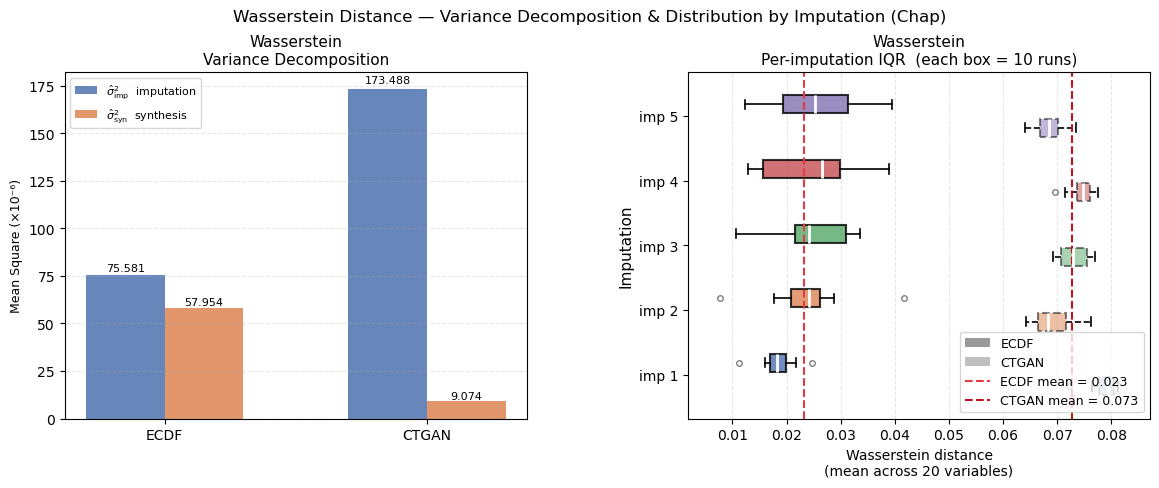

Saved: /Users/hazel/Dropbox/jinyuan/synthetic_data/review_paper/STDG-evaluation-metrics/notebooks/Dataset 1 - Chap/Synthetic data evaluation/Resemblance/UNIVARIATE RESEMBLANCE RESULTS/combined_decomp_boxplot_wasserstein_chap.svg


In [23]:
METRIC       = 'wasserstein'
METRIC_LABEL = 'Wasserstein'
IMP_IDS      = sorted(df_ds['imp_id'].unique())
IMP_PALETTE  = dict(zip(IMP_IDS, ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']))
METHODS      = ['ecdf', 'ctgan']

col    = f'{METRIC}_mean'
vals   = df_ds[col]
margin = (vals.max() - vals.min()) * 0.08
xlim   = (max(0.0, vals.min() - margin), vals.max() + margin)

fig, (ax_bar, ax_box) = plt.subplots(1, 2, figsize=(14, 4.5))
fig.subplots_adjust(wspace=0.35)

# ── LEFT: variance decomposition bar chart ──────────────────────────────────
x = np.arange(2)
w = 0.30
colors_bar = {'MS_imputation': '#4C72B0', 'MS_synthesis': '#DD8452'}

ms_imp, ms_syn = [], []
for method in METHODS:
    r = df_decomp[(df_decomp['method'] == method) & (df_decomp['metric'] == METRIC)].iloc[0]
    ms_imp.append(r['MS_imputation'] * 1e6)
    ms_syn.append(r['MS_synthesis']  * 1e6)

b_imp = ax_bar.bar(x - w/2, ms_imp, w,
                   label=r'$\hat{\sigma}^2_{\mathrm{imp}}$  imputation',
                   color=colors_bar['MS_imputation'], alpha=0.85)
b_syn = ax_bar.bar(x + w/2, ms_syn, w,
                   label=r'$\hat{\sigma}^2_{\mathrm{syn}}$  synthesis',
                   color=colors_bar['MS_synthesis'],  alpha=0.85)

for bars in [b_imp, b_syn]:
    for rect in bars:
        h = rect.get_height()
        ax_bar.text(rect.get_x() + rect.get_width() / 2, h * 1.01,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(['ECDF', 'CTGAN'], fontsize=10)
ax_bar.set_ylabel('Mean Square (×10⁻⁶)', fontsize=9)
ax_bar.set_title(f'{METRIC_LABEL}\nVariance Decomposition', fontsize=11)
ax_bar.legend(fontsize=8)
ax_bar.grid(axis='y', alpha=0.3, ls='--')

# ── RIGHT: per-imputation boxplot (ECDF + CTGAN overlaid) with mean lines ──
offsets     = {'ecdf': +0.18, 'ctgan': -0.18}
alphas      = {'ecdf': 0.80,  'ctgan': 0.50}
lstyles     = {'ecdf': '-',   'ctgan': '--'}
mean_colors = {'ecdf': '#e63946', 'ctgan': '#c1121f'}

for method in METHODS:
    sub  = df_ds[df_ds['method'] == method]
    data = [sub[sub['imp_id'] == imp][col].values for imp in IMP_IDS]
    pos  = [i + offsets[method] for i in range(1, 6)]

    bp = ax_box.boxplot(
        data,
        vert         = False,
        patch_artist = True,
        positions    = pos,
        widths       = 0.28,
        medianprops  = dict(color='white', linewidth=2),
        whiskerprops = dict(linewidth=1.2, linestyle=lstyles[method]),
        capprops     = dict(linewidth=1.2),
        flierprops   = dict(marker='o', markersize=4, alpha=0.5),
    )
    for box, imp in zip(bp['boxes'], IMP_IDS):
        box.set_facecolor(IMP_PALETTE[imp])
        box.set_alpha(alphas[method])
        box.set_linestyle(lstyles[method])
        box.set_linewidth(1.5)

    m = sub[col].mean()
    ax_box.axvline(m, color=mean_colors[method], lw=1.5, ls='--',
                   label=f'{method.upper()} mean = {m:.3f}')

ax_box.set_xlim(xlim)
ax_box.set_yticks(range(1, 6))
ax_box.set_yticklabels([f'imp {int(i)}' for i in IMP_IDS], fontsize=10)
ax_box.set_xlabel(f'{METRIC_LABEL} distance\n(mean across {n_vars} variables)', fontsize=10)
ax_box.set_ylabel('Imputation', fontsize=11)
ax_box.grid(axis='x', alpha=0.3, linestyle='--')
ax_box.set_title(f'{METRIC_LABEL}\nPer-imputation IQR  (each box = 10 runs)', fontsize=11)

box_handles = [
    Patch(facecolor='grey', alpha=0.80, label='ECDF'),
    Patch(facecolor='grey', alpha=0.50, linestyle='--', label='CTGAN'),
]
mean_handles = ax_box.get_legend_handles_labels()
ax_box.legend(handles=box_handles + list(mean_handles[0][-2:]),
              fontsize=9, loc='lower right')

fig.suptitle('Wasserstein Distance — Variance Decomposition & Distribution by Imputation (Chap)',
             fontsize=12, y=1.02)

fname = os.path.join(OUT_DIR, f'combined_decomp_boxplot_{METRIC}_chap.svg')
fig.savefig(fname, bbox_inches='tight')
plt.show()
print(f"Saved: {fname}")